# **STAGE 3 - VISUALISATION**

## Objectives

* In this final section, I will use data visualisation tools to assess the following hypotheses:


|**Hypothesis**| **Description**|
|--------------|----------------|
|**H1**| Donors aged 50 - 65 give more per transaction than other age brackets |


## Inputs

* The input needed for this notebook is the cleaned dataset created in **Stage 2 - ETL**. 
* The relative path for this .csv file is: `datasets/cleaned-data/animal_charity_donation_records_cleaned.csv`

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/wildlife-charity-giving-analytics/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/wildlife-charity-giving-analytics'

---

# Import Packages and Libraries

In order to read `animal_charity_donation_records_cleaned.csv` and created data visualisations to analyse my 5 hypotheses, I need to import the following libraries and packages:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

---

# Data Type Changes Prior to Visualisation

* In **Stage 2 - ETL**, we looked at Transforming some of the columns through changing their data type: specifically, `age_group` and `donation_date`. 
* When saving the cleaned DataFrame to a new .csv file to be used in this notebook, the data type changes were lost and will need to be repeated in this notebook as well.
* Because a greater explanation for the process was given in the previous notebook, I will simply make these changes here and confirm that they have been implemented.

* Firstly, I will load in the cleaned dataset to be read.

In [5]:
# Load the cleaned data
df_cleaned = pd.read_csv("datasets/cleaned-data/animal_charity_donation_records_cleaned.csv")

# Display the first few rows of the cleaned data
df_cleaned.head(2)

,anonymised_donor_id,age_group,country,donation_amount,donation_date,payment_method,newsletter_opt_in,referral_channel,sector,campaign,donation_year,donation_month,donation_day,gender_Female,gender_Male,donation_type_Monthly,gender,donation_type,donation_amount_category
0,f887acec7d236a724e0cd0df5112c6a7641e2b6867aeb9...,50-65,UK,115.31,2024-10-24,Paypal,False,Website,Real Estate,Rescue Orphaned Gorillas,2024,10,3,1,0,1,Female,Monthly,High
1,db1fd2f0b9dd06646c1713945fda992a7250b512cce720...,50-65,USA,8.60,2024-06-21,Bank Transfer,False,Online advertising,Logistics,Rescue Orphaned Gorillas,2024,6,4,1,0,0,Female,One-time,Low


* Then, I will order and change data type for `age_group`.

Data type of 'age_group' column after conversion: category



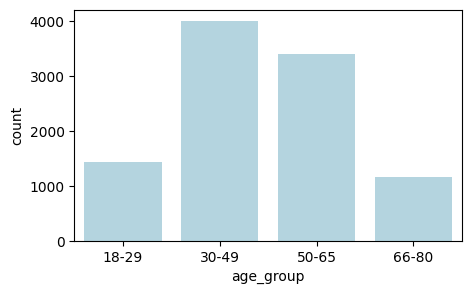

In [6]:
# Order the age_group column and change to categorical data type

# First, define the order of the age groups
age_group_order = ["18-29", "30-49", "50-65", "66-80"]

# Change the data type of the "age_group" column to categorical and parse with the specified order
df_cleaned["age_group"] = pd.Categorical(df_cleaned["age_group"], categories=age_group_order, ordered=True)

# Check the data type of the column "age_group" after conversion
print(f"Data type of 'age_group' column after conversion: {df_cleaned['age_group'].dtype}\n")

# Plot age ranges after ordering and changing the data type to confirm the change has been made
fig, axes = plt.subplots(figsize=(5, 3))
sns.countplot(data=df_cleaned, x="age_group", color="lightblue")
plt.show()

* Finally, I will change the data type for `donation_date`.
* *Note*: I don't foresee needing to use the entire donation date in any of these hypotheses below, but I will change the data type just in case.

In [7]:
# Change the data type of the "donation_date" column to datetime
df_cleaned["donation_date"] = pd.to_datetime(df_cleaned["donation_date"], format="%Y-%m-%d")

# Check the data type of the column "donation_date" after conversion
print(f"Data type of 'donation_date' column after conversion: {df_cleaned["donation_date"].dtype}\n")

# Print the first few rows of the dataset to verify the changes
print(f"Sample values from 'donation_date' column after conversion:\n{df_cleaned["donation_date"].head()}")

Data type of 'donation_date' column after conversion: datetime64[ns]

Sample values from 'donation_date' column after conversion:
0   2024-10-24
1   2024-06-21
2   2024-08-21
3   2023-10-09
4   2024-09-01
Name: donation_date, dtype: datetime64[ns]


---

# Hypothesis 1

* This section will look to compare **donation amount** with **donor age group**


|**H1**| Donors aged 50 - 65 give more per transaction than other age brackets |
|--------------|---------------|


* The first thing I am going to do is create a violin plot that shows the distribution of donation amounts per age group.

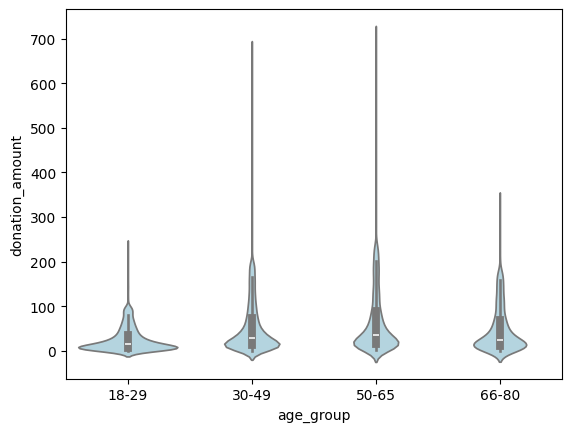

In [8]:
# Create a violin plot to visualise donation amounts given by age group
sns.violinplot(data=df_cleaned, x="age_group", y="donation_amount", color="lightblue")
plt.show()

* Whilst this plot gives us some insights into giving amounts, it does not definitively tell us which age group on average gives the most per donation.
* What can we tell?
    * We can gather that in the 18-29 category, most donations are very similar in size, the sit at a lower level and there are very few outliers in terms of very high donations. 
    * We can tell from the violin plot that the biggest donation was made by someone in the 50-65 age group, given that this sits higher than the other three - however, the plots for 30-49, 50-65 and 66-80 appear too similar to draw any meaningful conclusions. 

* Instead, I am going to work out the mean donation amount for each age group and present this in a bar graph.

In [9]:
# First, calculate the mean donation amount for each age group
age_mean_donations = df_cleaned.groupby("age_group", observed=False)["donation_amount"].mean()

# Show these mean doantion amounts
print(f"Mean donation amounts by age group:\n{age_mean_donations}")

Mean donation amounts by age group:
age_group
18-29    25.855845
30-49    51.950155
50-65    63.354449
66-80    48.532751
Name: donation_amount, dtype: float64


* *Troubleshooting Issues*: When I first completed this code, I received a FutureWarning error ("The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.") 
Having looked up the [pandas.DataFrame.groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) documentation, I found that the `observed` argument relates to categorical grouped data, where `True` shows only the groups where there are values, whereas `False` shows all. Given that I completed cleaning already in **Stage 2 - ETL**, I expected the results to be the same and practiced with both before making a decision.

* I was unsure how best to convert this Pandas Series into a Bar Plot, so I made the decision to try and convert the Series into a Dataframe so that I could use two column names `age_group` and `mean_donation_amount` as my `x` and `y` axes. I found a very useful **Stack Overflow** forum entry with a worked example using `.to_frame()`.
* Because I also needed to ensure that the mean donation amounts were rounded to 2 decimal places (as currency), I decided to use method chaining for the functions applied to `age_mean_donations` to make it clearer to read.

In [10]:
# Create a DataFrame for the mean donations by age group, using the above pandas Series

df_mean_donations = (age_mean_donations
                     .to_frame()
                     .reset_index()
                     .round(2))
df_mean_donations

,age_group,donation_amount
0,18-29,25.86
1,30-49,51.95
2,50-65,63.35
3,66-80,48.53


In [11]:
# Rename the "donation_amount" column to "mean_donation_amount"
df_mean_donations =df_mean_donations.rename(columns={"donation_amount": "mean_donation_amount"})
df_mean_donations

,age_group,mean_donation_amount
0,18-29,25.86
1,30-49,51.95
2,50-65,63.35
3,66-80,48.53


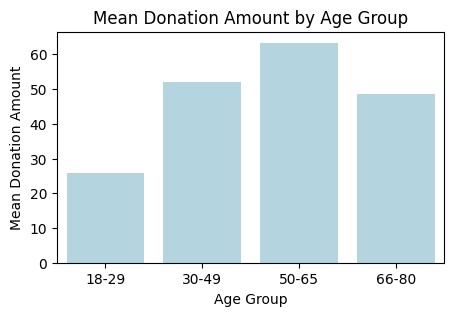

In [12]:
# Create a Bar Chart using Seaborn to show the mean donation amounts by age group

fig, axes = plt.subplots(figsize=(5, 3))

sns.barplot(data=df_mean_donations, x="age_group", y="mean_donation_amount", color="lightblue")

plt.title("Mean Donation Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Donation Amount")
plt.show()

* This bar plot is a much better means of demonstrating the average donation amount given by an individual in each of the age categories.

**RESULT**
* Hypothesis 1 has been validated as being true. 
* As we can see from the bar plot and from our mean donations DataFrame, donors who fall in the age bracket 50-65 give more on average (€63.35).

---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---